In [1]:
import pickle
import time
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari
print(nth_prime(100))

541


In [8]:
import pickle
import time
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari


pari.allocatemem(6*10**9) 
print(f"PARI stack size set to: {pari.stacksize() / 1e9:.2f} GB")


D = delta_qexp(545) 
print(nth_prime(100))
print(D[nth_prime(100)])

PARI stack size set to 6000000000 bytes, maximum size set to 6000001024
PARI stack size set to: 6.00 GB
541
-1695266465052058


In [4]:
sum?

Signature:      sum(expression, *args, **kwds)
Docstring:     
Return the symbolic sum \sum_{v = a}^b expression with respect to the
variable v with endpoints a and b.

INPUT:

* "expression" -- a symbolic expression

* "v" -- a variable or variable name

* "a" -- lower endpoint of the sum

* "b" -- upper endpoint of the sum

* "algorithm" -- (default: "'maxima'")  one of

  * "'maxima'" -- use Maxima (the default)

  * "'maple'" -- (optional) use Maple

  * "'mathematica'" -- (optional) use Mathematica

  * "'giac'" -- (optional) use Giac

  * "'sympy'" -- use SymPy

EXAMPLES:

   sage: k, n = var('k,n')
   sage: sum(k, k, 1, n).factor()
   1/2*(n + 1)*n

   sage: sum(1/k^4, k, 1, oo)
   1/90*pi^4

   sage: sum(1/k^5, k, 1, oo)
   zeta(5)


  This function only works with symbolic expressions. To sum any other
  objects like list elements or function return values, please use
  python summation, see
  http://docs.python.org/library/functions.html#sumIn particular, this
  does not work

In [12]:
add([1,2])

3

In [22]:
from sage.all import *


def h_sequence_from_j(j_list):
    j_lenth = len(j_list)
    h = [QQ(1)]   # h_0 = 1
    for n in range(1, j_lenth + 1):
        s = sum(j_list[r-1] * h[n-r] for r in range(1, n))
        h_n = (j_list[n-1] + s) / n
        h.append(h_n)
    return h

def j_sequence_from_h(h_list):
    if h_list[0] != 1:
        raise ValueError("Must have h_0 = 1")
    h_lenth= len(h_list) - 1
    j = []
    for n in range(1, h_lenth + 1):
        s = sum(j[r-1] * h_list[n-r]
                for r in range(1, n))
        j_n = n*h_list[n] - s
        j.append(j_n)
    return j

j_list=[1,2,3]
test1=h_sequence_from_j(j_list)
print(test1)
test2=j_sequence_from_h(test1)
print(test2)
print("============================================")
j_list=[2,3,5,7,11]
test1=h_sequence_from_j(j_list)
print(test1)
test2=j_sequence_from_h(test1)
print(test2)

[1, 1, 3/2, 13/6]
[1, 2, 3]
[1, 2, 7/2, 6, 79/8, 321/20]
[2, 3, 5, 7, 11]


deformed_h_list[0]: 1
n: 1 elapsed: 0.0004378835360209147
n: 2 elapsed: 0.0004770000775655111
n: 3 elapsed: 0.0004851818084716797
n: 4 elapsed: 0.0004950165748596191
n: 5 elapsed: 0.00051193634668986
n: 6 elapsed: 0.0005310853322347005
n: 7 elapsed: 0.0005603988965352376
n: 8 elapsed: 0.0005971153577168782
n: 9 elapsed: 0.000642700990041097
n: 10 elapsed: 0.0006967663764953613
n: 11 elapsed: 0.0007555842399597168
n: 12 elapsed: 0.0008149822552998861
n: 13 elapsed: 0.0008916497230529785
n: 14 elapsed: 0.0010007659594217936
n: 15 elapsed: 0.0011019349098205567
n: 16 elapsed: 0.0012150168418884276
n: 17 elapsed: 0.0013524969418843588
n: 18 elapsed: 0.0014963308970133463
n: 19 elapsed: 0.0016522010167439778
n: 20 elapsed: 0.0018138647079467773
n: 21 elapsed: 0.0019962151845296225
n: 22 elapsed: 0.0022074302037556966
n: 23 elapsed: 0.0024316827456156414
n: 24 elapsed: 0.0026529828707377114
n: 25 elapsed: 0.002910800774892171
n: 26 elapsed: 0.003204902013142904
n: 27 elapsed: 0.0035093665122

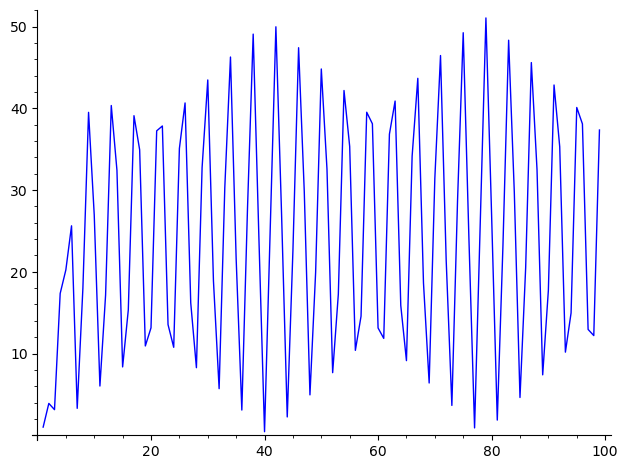

In [25]:
from sage.all import *
import pickle
import time
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari
start=time.time()
precision_bits = 100
CC = ComplexField(precision_bits)
x = polygen(QQ)

def h_sequence_from_j(j_list):
    j_lenth = len(j_list)
    h = [QQ(1)]   # h_0 = 1
    for n in range(1, j_lenth + 1):
        s = sum(j_list[r-1] * h[n-r] for r in range(1, n))
        h_n = (j_list[n-1] + s) / n
        h.append(h_n)
    return h

def j_sequence_from_h(h_list):
    if h_list[0] != 1:
        raise ValueError("Must have h_0 = 1")
    h_lenth= len(h_list) - 1
    j = []
    for n in range(1, h_lenth + 1):
        s = sum(j[r-1] * h_list[n-r]
                for r in range(1, n))
        j_n = n*h_list[n] - s
        j.append(j_n)
    return j

D = delta_qexp(545) 
h_list=[1]+[D[nth_prime(k)] for k in range(1,101)]
j_list=j_sequence_from_h(h_list)
c=1
deformed_j_list=[c]+j_list
deformed_h_list=h_sequence_from_j(deformed_j_list)
print("deformed_h_list[0]:",deformed_h_list[0])

def deformed_h(n):
    return deformed_h_list[n]
    
roots_list=[]    
chi_list=[]
mins_list=[]
for n in range(1,100):
    print("n:",n,"elapsed:",(time.time()-start)/60)
    chi=0
    for r in range(0,n+1):
        chi+=binomial(n,r)*factorial(r)*deformed_h(r)*(-1)**r*x**(n-r)
    chi_list.append((n,chi))
    roots = chi.roots(ring=CC, multiplicities=False)
    roots_list.append((n, roots))
    aar = [r.abs() for r in roots]
    if aar:
        minn = min(aar)
        mins_list.append((n, minn))

p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()

with open('/Users/barrybrent/data2/run15may26no1.txt', 'wb') as wfile:
    pickle.dump(deformed_j_list, wfile) 
with open('/Users/barrybrent/data2/run15may26no2.txt', 'wb') as wfile:
    pickle.dump(deformed_h_list, wfile)
with open('/Users/barrybrent/data2/run15may26no3.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile)






In [27]:
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari
print(nth_prime(500))

3571


deformed_h_list[0]: 1
n: 1 elapsed: 0.05102768341700236
n: 2 elapsed: 0.051045616467793785
n: 3 elapsed: 0.0510501503944397
n: 4 elapsed: 0.05105760097503662
n: 5 elapsed: 0.05106896956761678
n: 6 elapsed: 0.051084268093109134
n: 7 elapsed: 0.05110863447189331
n: 8 elapsed: 0.051143519083658856
n: 9 elapsed: 0.0511772354443868
n: 10 elapsed: 0.05121793349583944
n: 11 elapsed: 0.051266018549601236
n: 12 elapsed: 0.05132338603337606
n: 13 elapsed: 0.05139266649881999
n: 14 elapsed: 0.05148640076319377
n: 15 elapsed: 0.05157143672307332
n: 16 elapsed: 0.05167109966278076
n: 17 elapsed: 0.05179118315378825
n: 18 elapsed: 0.0519264817237854
n: 19 elapsed: 0.05207981665929159
n: 20 elapsed: 0.05223535299301148
n: 21 elapsed: 0.0524115522702535
n: 22 elapsed: 0.05261798699696859
n: 23 elapsed: 0.05283515055974324
n: 24 elapsed: 0.053051253159840904
n: 25 elapsed: 0.05330196619033813
n: 26 elapsed: 0.053588302930196126
n: 27 elapsed: 0.053884987036387125
n: 28 elapsed: 0.054205818970998125
n: 

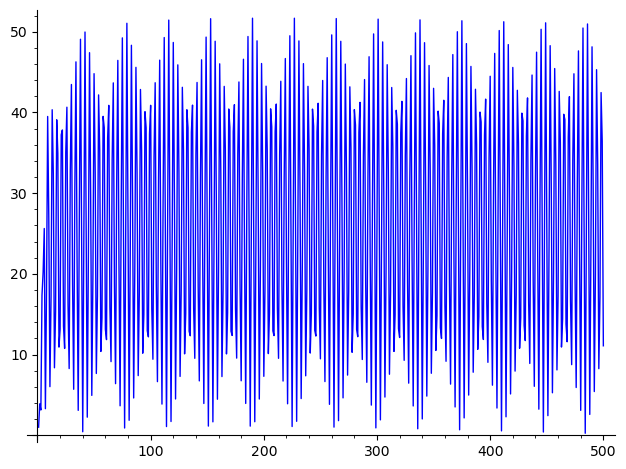

In [29]:
from sage.all import *
import pickle
import time
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari
start=time.time()
precision_bits = 100
CC = ComplexField(precision_bits)
x = polygen(QQ)

def h_sequence_from_j(j_list):
    j_lenth = len(j_list)
    h = [QQ(1)]   # h_0 = 1
    for n in range(1, j_lenth + 1):
        s = sum(j_list[r-1] * h[n-r] for r in range(1, n))
        h_n = (j_list[n-1] + s) / n
        h.append(h_n)
    return h

def j_sequence_from_h(h_list):
    if h_list[0] != 1:
        raise ValueError("Must have h_0 = 1")
    h_lenth= len(h_list) - 1
    j = []
    for n in range(1, h_lenth + 1):
        s = sum(j[r-1] * h_list[n-r]
                for r in range(1, n))
        j_n = n*h_list[n] - s
        j.append(j_n)
    return j

D = delta_qexp(4000) 
h_list=[1]+[D[nth_prime(k)] for k in range(1,501)]
j_list=j_sequence_from_h(h_list)
c=1
deformed_j_list=[c]+j_list
deformed_h_list=h_sequence_from_j(deformed_j_list)
print("deformed_h_list[0]:",deformed_h_list[0])

def deformed_h(n):
    return deformed_h_list[n]
    
roots_list=[]    
chi_list=[]
mins_list=[]
for n in range(1,501):
    print("n:",n,"elapsed:",(time.time()-start)/60)
    chi=0
    for r in range(0,n+1):
        chi+=binomial(n,r)*factorial(r)*deformed_h(r)*(-1)**r*x**(n-r)
    chi_list.append((n,chi))
    roots = chi.roots(ring=CC, multiplicities=False)
    roots_list.append((n, roots))
    aar = [r.abs() for r in roots]
    if aar:
        minn = min(aar)
        mins_list.append((n, minn))

p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()

with open('/Users/barrybrent/data2/run15may26no4.txt', 'wb') as wfile:
    pickle.dump(deformed_j_list, wfile) 
with open('/Users/barrybrent/data2/run15may26no5.txt', 'wb') as wfile:
    pickle.dump(deformed_h_list, wfile)
with open('/Users/barrybrent/data2/run15may26no6.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile)
with open('/Users/barrybrent/data2/run15may26no7.txt', 'wb') as wfile:
    pickle.dump(chi_list, wfile)

In [30]:
with open('/Users/barrybrent/data2/run15may26no14.txt', 'wb') as wfile:
    pickle.dump(deformed_j_list, wfile) 
with open('/Users/barrybrent/data2/run15may26no15.txt', 'wb') as wfile:
    pickle.dump(deformed_h_list, wfile)
with open('/Users/barrybrent/data2/run15may26no16.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile)
with open('/Users/barrybrent/data2/run15may26no17.txt', 'wb') as wfile:
    pickle.dump(chi_list, wfile)
with open('/Users/barrybrent/data2/run15may26no18.txt', 'wb') as wfile:
    pickle.dump(roots_list, wfile)

In [32]:
lc=len(chi_list)
print(lc)

500


In [34]:
chi_list_a=chi_list[:300]
with open('/Users/barrybrent/data2/run15may26no17a.txt', 'wb') as wfile:
    pickle.dump(chi_list_a, wfile)

In [35]:
chi_list_b=chi_list[301:400]
with open('/Users/barrybrent/data2/run15may26no17b.txt', 'wb') as wfile:
    pickle.dump(chi_list_b, wfile)

In [36]:
chi_list_c=chi_list[401:450]
with open('/Users/barrybrent/data2/run15may26no17c.txt', 'wb') as wfile:
    pickle.dump(chi_list_c, wfile)

In [39]:
chi_list_d=chi_list[450:480]
with open('/Users/barrybrent/data2/run15may26no17d.txt', 'wb') as wfile:
    pickle.dump(chi_list_d, wfile)

In [40]:
chi_list_e=chi_list[481:500]
with open('/Users/barrybrent/data2/run15may26no17e.txt', 'wb') as wfile:
    pickle.dump(chi_list_e, wfile)